# Phase 5 - K-means Rhythm-state classification

**Goal**: classify each moment of fermentation into a rhythmic state (quiet, stable, bursty, very active) using K-means clustering.
<br>The cluster assigned to each event will be used in Phase 7

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_CLEAN_DIR = '../data_clean'
df_feat = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_features.csv'))
print(f'Loaded {len(df_feat):,} feature vectors')

Loaded 4,312 feature vectors


## 5.1 Pick featuers for clustering

In [ ]:
state_features = ['density_1s', 'density_3s', 'density_10s', 'density_60s',
                  'iei_prev', 'iei_prev2',
                  'recent_cv_5s', 'burst_score']

X = df_feat[state_features].fillna(0).values
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (4312, 8)


## 5.2 Choose k

k=2: silhouette=0.635, balance=0.603
k=3: silhouette=0.680, balance=0.501
k=4: silhouette=0.588, balance=0.479
k=5: silhouette=0.582, balance=0.484
k=6: silhouette=0.274, balance=0.611
k=7: silhouette=0.291, balance=0.598
k=8: silhouette=0.307, balance=0.586
k=9: silhouette=0.315, balance=0.570
k=10: silhouette=0.310, balance=0.599


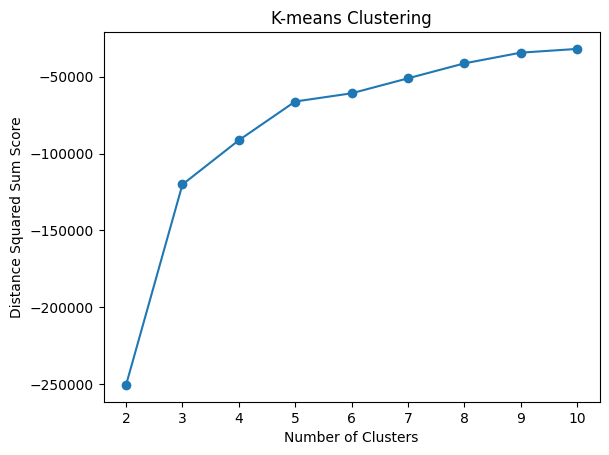

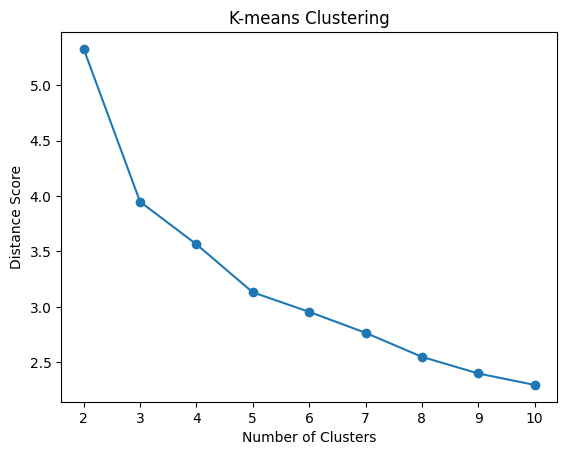

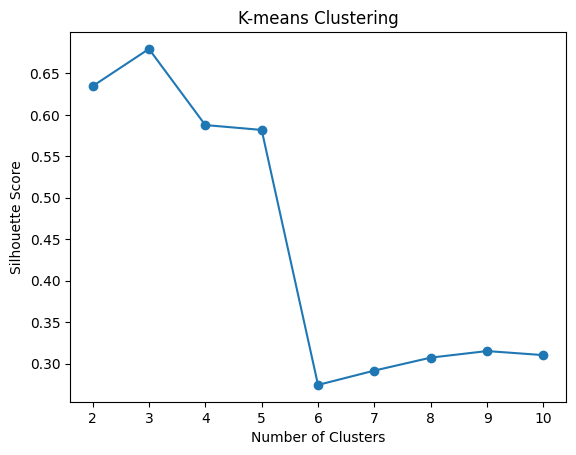

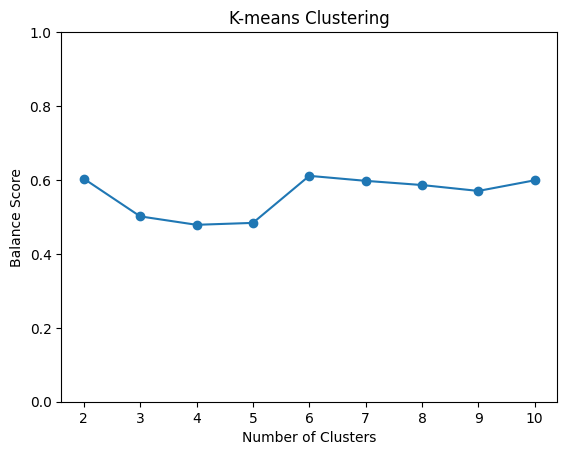

In [7]:
def balance_score(predictions):
    counts = np.bincount(predictions)
    n = len(predictions)
    k = len(counts)
    expected = n / k
    deviation = np.abs(counts - expected).sum() / (2 * n)
    return 1.0 - deviation

# Helper: distance score (average distance from each point to its cluster center)
def distance_score(X, predictions, model):
    centers = model.cluster_centers_
    total_dist = 0
    for i, label in enumerate(predictions):
        d = np.linalg.norm(X[i] - centers[label])
        total_dist += d
    return total_dist / len(X)


# Try different numbers of clusters for K-means
num_clusters = list(range(2, 11))

# Collect scores
score_scores = []
distance_scores = []
silhouette_scores_list = []
balance_scores = []

for n in num_clusters:
    mm = KMeans(n_clusters=n, random_state=1010)
    pred = mm.fit_predict(X)
    score_scores.append(mm.score(X))
    distance_scores.append(distance_score(X, pred, mm))
    silhouette_scores_list.append(silhouette_score(X, pred))
    balance_scores.append(balance_score(pred))
    print(f'k={n}: silhouette={silhouette_scores_list[-1]:.3f}, balance={balance_scores[-1]:.3f}')


# Plot 1: Distance Squared Sum (mm.score)
plt.plot(num_clusters, score_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Distance Squared Sum Score")
plt.title("K-means Clustering")
plt.show()

# Plot 2: Distance Score
plt.plot(num_clusters, distance_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Distance Score")
plt.title("K-means Clustering")
plt.show()

# Plot 3: Silhouette Score
plt.plot(num_clusters, silhouette_scores_list, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-means Clustering")
plt.show()

# Plot 4: Balance Score
plt.plot(num_clusters, balance_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Balance Score")
plt.title("K-means Clustering")
plt.ylim([0, 1])
plt.show()

Based on the graphs, I chose k=4.
k=5 could be a good choice as well, but I want to make the group as simple as possible and there is little difference between 4 and 5. 

In [18]:
# Cluster with chosen n
n_clusters = 4

km_model = KMeans(n_clusters=n_clusters, random_state=1010)
km_predicted = km_model.fit_predict(X)

print(f'Clustered into {n_clusters} groups:')
print(pd.Series(km_predicted).value_counts().sort_index())

# Add cluster label to the dataframe
df_feat['cluster'] = km_predicted

# Look at cluster centers
centers_df = pd.DataFrame(km_model.cluster_centers_, columns=state_features)
print('\nCluster centers (in standardized space):')
centers_df

Clustered into 4 groups:
0    3326
1     363
2     494
3     129
Name: count, dtype: int64

Cluster centers (in standardized space):


,density_1s,density_3s,density_10s,density_60s,iei_prev,iei_prev2,recent_cv_5s,burst_score
0,0.155776,0.245694,0.280276,0.137650,-0.251592,0.554900,0.187967,0.028679
1,-0.896876,-1.037767,-1.177302,-0.508063,2.606212,20.030885,-0.633223,-1.005872
2,-0.303732,-0.709084,-0.778591,-0.326815,-0.164435,-10.745167,-0.633223,0.415849
3,-0.325916,-0.691678,-0.923676,-0.864244,-0.217945,-29.728278,-0.633223,0.495575


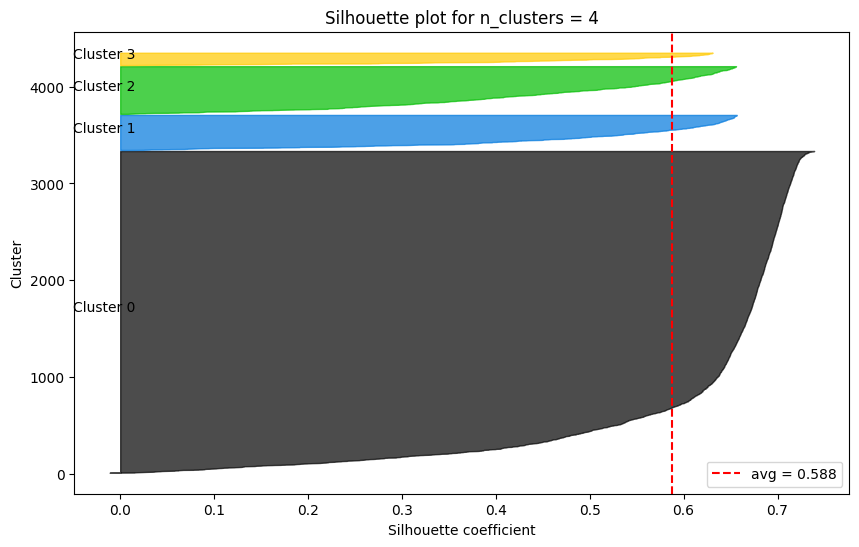

In [19]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Compute silhouette values for each point
sample_silhouette_values = silhouette_samples(X, km_predicted)
silhouette_avg = silhouette_score(X, km_predicted)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(n_clusters):
    # Get silhouette values for cluster i, then sort
    ith_cluster_values = sample_silhouette_values[km_predicted == i]
    ith_cluster_values.sort()
    
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # Cluster label in the middle of the bar
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color='red', linestyle='--',
           label=f'avg = {silhouette_avg:.3f}')
ax.set_title(f'Silhouette plot for n_clusters = {n_clusters}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.show()

Although the cluster 0 seems to be too large, it makes sense thinking about the fermentation feature.
<br> It's quiet most of the time but gets active sometimes.

I wanted to inspect the cluster to understand the characteristics of each - which I analyzed in 5.4

## 5.3 Clustering with k=4

In [21]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
df_feat['cluster'] = kmeans.labels_

print(f'Clustered into {K} groups:')
print(df_feat['cluster'].value_counts().sort_index())

Clustered into 4 groups:
cluster
0    3327
1     363
2     129
3     493
Name: count, dtype: int64


In [22]:
rows = []
for c in range(K):
    sub = df_feat[df_feat['cluster'] == c]
    rows.append({
        'cluster': c,
        'n_events': len(sub),
        'pct': f'{len(sub)/len(df_feat)*100:.1f}%',
        'mean_density_1s':  sub['density_1s'].mean(),
        'mean_density_3s':  sub['density_3s'].mean(),
        'mean_density_60s': sub['density_60s'].mean(),
        'median_iei':       sub['iei_prev'].median(),
        'mean_burst':       sub['burst_score'].mean(),
        'mean_recent_cv':   sub['recent_cv_5s'].mean(),
    })

summary = pd.DataFrame(rows)
print('Cluster summary (standardized features):')
print(summary.round(3))

Cluster summary (standardized features):
   cluster  n_events    pct  mean_density_1s  mean_density_3s  \
0        0      3327  77.2%            0.155            0.245   
1        1       363   8.4%           -0.897           -1.038   
2        2       129   3.0%           -0.326           -0.692   
3        3       493  11.4%           -0.303           -0.709   

   mean_density_60s  median_iei  mean_burst  mean_recent_cv  
0             0.137      -0.439       0.028           0.187  
1            -0.508       2.233      -1.006          -0.633  
2            -0.864      -0.414       0.496          -0.633  
3            -0.327      -0.421       0.419          -0.633  


### Characteristics of each cluster

**Cluster0: baseline** - constant fermentation state with density higher than other clusters

**Cluster1: after_silence** - fermentation after silence for a while with density less than other clusters and low burst score

**Cluster2: isolated_burst** - burst fermentation after silence with lowest density_60s and high burst score

**Cluster3: small_burst** - burst fermentation with moderate constant fermentation (density_60s is the 2nd highest and high burst score)

In [27]:
# Label clusters

cluster_to_label = {
    0: 'baseline',          
    1: 'after_silence',     
    2: 'isolated_burst',   
    3: 'small_burst',       
}
df_feat['cluster_label'] = df_feat['cluster'].map(cluster_to_label)

print('Cluster labels:')
for c, label in cluster_to_label.items():
    n = (df_feat['cluster'] == c).sum()
    print(f'  Cluster {c} ({label}): {n:,} events')

Cluster labels:
  Cluster 0 (baseline): 3,327 events
  Cluster 1 (after_silence): 363 events
  Cluster 2 (isolated_burst): 129 events
  Cluster 3 (small_burst): 493 events


## 5.5 Cluster timeline

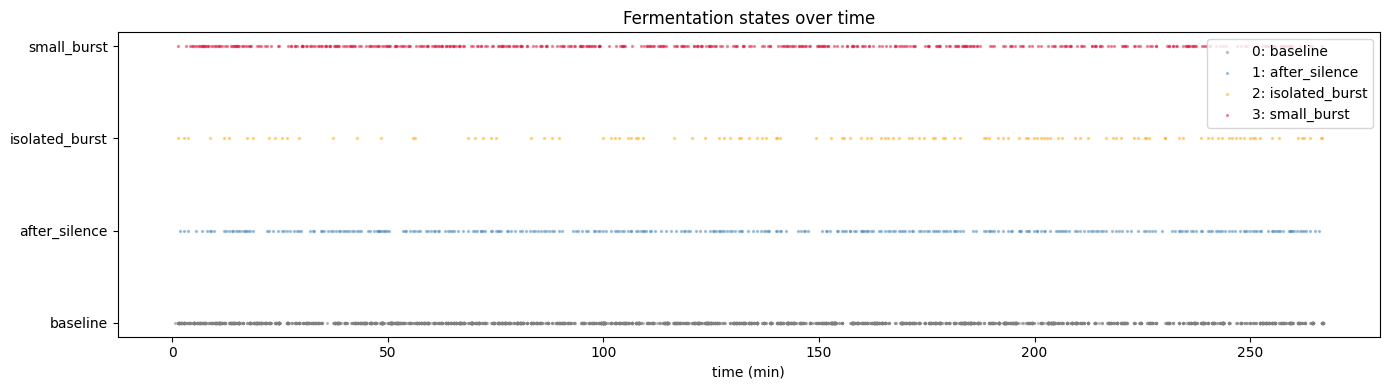

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = {0: 'gray', 1: 'steelblue', 2: 'orange', 3: 'crimson'}
labels = {
    0: 'baseline',          
    1: 'after_silence',     
    2: 'isolated_burst',   
    3: 'small_burst',       
}
label_colors = {labels[i]: colors[i] for i in range(K)}
for c in range(K):
    sub = df_feat[df_feat['cluster'] == c]
    label = cluster_to_label[c]
    ax.scatter(sub['t_rel']/60, [c]*len(sub),
               s=2, alpha=0.4, color=label_colors[label],
               label=f'{c}: {label}')
ax.set_yticks(range(K))
ax.set_yticklabels([cluster_to_label[i] for i in range(K)])
ax.set_xlabel('time (min)')
ax.set_title('Fermentation states over time')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/plots/17_cluster_timeline.png', dpi=120)
plt.show()

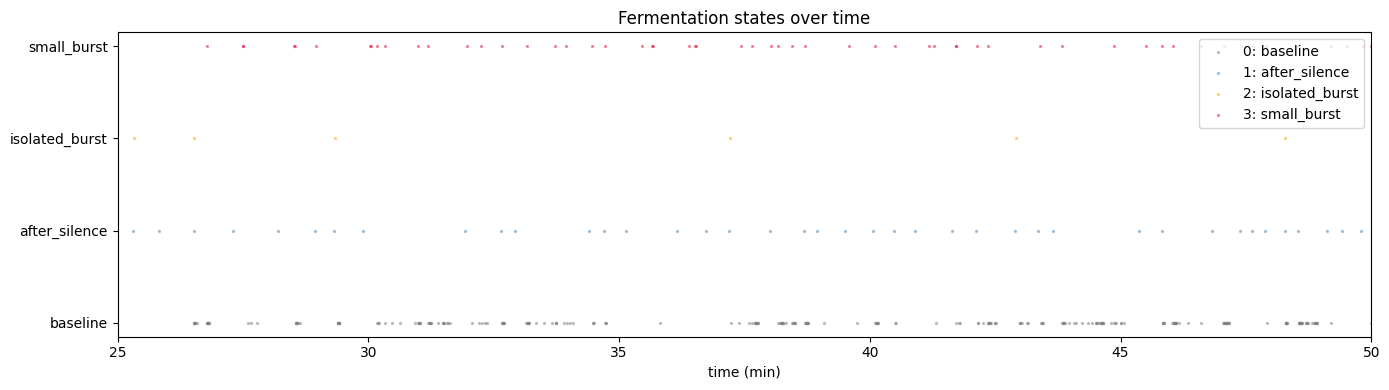

In [32]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = {0: 'gray', 1: 'steelblue', 2: 'orange', 3: 'crimson'}
labels = {
    0: 'baseline',          
    1: 'after_silence',     
    2: 'isolated_burst',   
    3: 'small_burst',       
}
label_colors = {labels[i]: colors[i] for i in range(K)}
for c in range(K):
    sub = df_feat[df_feat['cluster'] == c]
    label = cluster_to_label[c]
    ax.scatter(sub['t_rel']/60, [c]*len(sub),
               s=2, alpha=0.4, color=label_colors[label],
               label=f'{c}: {label}')
ax.set_yticks(range(K))
ax.set_xlim(25,50)
ax.set_yticklabels([cluster_to_label[i] for i in range(K)])
ax.set_xlabel('time (min)')
ax.set_title('Fermentation states over time')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/plots/17_cluster_timeline_25-50.png', dpi=120)
plt.show()

## 5.6 Save

In [33]:
import pickle
out_csv = os.path.join(DATA_CLEAN_DIR, 'all_events_clustered.csv')
df_feat.to_csv(out_csv, index=False)

out_pkl = os.path.join(DATA_CLEAN_DIR, 'kmeans_model.pkl')
with open(out_pkl, 'wb') as f:
    pickle.dump({'kmeans': kmeans, 'cluster_to_label': cluster_to_label,
                 'state_features': state_features}, f)

print(f'Saved:')
print(f'  {out_csv}')
print(f'  {out_pkl}')

Saved:
  ../data_clean/all_events_clustered.csv
  ../data_clean/kmeans_model.pkl
